In [1]:
from utils import RAT
import numpy as np
import scipy.ndimage
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import scipy.stats
import numpy as np
import scipy.ndimage
from sklearn.linear_model import Ridge , LinearRegression

from sklearn.model_selection import train_test_split

In [7]:
# Load one session 
RAT_ID = 2 
LIGHTING = "light"  
     
rat = RAT(n=RAT_ID, lighting=LIGHTING, filter_speed=True) 

t = rat.T  # (s), starts at 0 
x = rat.X  # (cm) 
y = rat.Y  # (cm) 
v = rat.V  # (cm / s)
# Choose which spikes to use 
spikes_by_cell = {} 
spikes_by_cell.update(rat.grid_mod1) 
spikes_by_cell.update(rat.grid_mod2) 
spikes_by_cell.update(rat.grid_mod3) 
    
print(f"duration_s={t[-1]:.1f}  n_cells={len(spikes_by_cell)}")


duration_s=1945.8  n_cells=205


# 1

In [6]:
import numpy as np
import scipy.ndimage
from sklearn.linear_model import Ridge , LinearRegression

from sklearn.model_selection import train_test_split

# 1. Setup Parameters
dt = 0.8  # time bins (s)
sigma_ms = 50  # Gaussian smoothing window (standard deviation in ms)
sigma_bins = (sigma_ms / 1000) / dt 

# Create time bins spanning the entire session
t_bins = np.arange(t[0], t[-1], dt)
n_bins = len(t_bins)
n_cells = len(spikes_by_cell)

# 2. Calculate Velocity (Ground Truth)
# We interpolate x and y to the new t_bins before taking the derivative
# x_interp = np.interp(t_bins, t, x)
# y_interp = np.interp(t_bins, t, y)

# vx = np.gradient(x_interp, dt)
# vy = np.gradient(y_interp, dt)

V = np.interp(t_bins , t , v) #np.column_stack([vx, vy]) # Target Matrix (T x 2)
# V  = v
# 3. Create Neural Response Matrix (R)
R = np.zeros((n_bins, n_cells))

for i, (cell_id, spike_times) in enumerate(spikes_by_cell.items()):
    # Histogram spikes into the defined time bins
    counts, _ = np.histogram(spike_times, bins=np.append(t_bins, t_bins[-1] + dt))
    
    # Apply Gaussian smoothing to get a continuous firing rate
    R[:, i] = scipy.ndimage.gaussian_filter1d(counts.astype(float), sigma=sigma_bins)

# 4. Preprocessing: Z-score the neural data
R_mean = np.mean(R, axis=0)
R_std = np.std(R, axis=0) + 1e-6 # Avoid division by zero
R_scaled = (R - R_mean) / R_std

# 5. Regression (Closed Form via Scikit-Learn)
# Using Ridge(alpha=0) is equivalent to the Normal Equation solution
X_train, X_test, y_train, y_test = train_test_split(R_scaled, V, test_size=0.2, shuffle=False)

# model = Ridge(alpha=1.0) # alpha > 0 adds regularization to handle correlated grid cells
model = LinearRegression() # alpha > 0 adds regularization to handle correlated grid cells
model.fit(X_train, y_train)

# 6. Evaluation
V_pred_train = model.predict(X_train)
score = model.score(X_train, y_train) # R-squared

print(f"train R^2 Decoder Score: {score:.4f}")
rmse_train = np.sqrt(mean_squared_error(V_pred_train, y_train))

print(f"train mean_squared_error : {rmse_train:.4f}")



V_pred = model.predict(X_test)
score = model.score(X_test, y_test) # R-squared

print(f"test R^2 Decoder Score: {score:.4f}")
rmse = np.sqrt(mean_squared_error(V_pred, y_test))

print(f"test mean_squared_error : {rmse:.4f}")



train R^2 Decoder Score: 0.4644
train mean_squared_error : 6.8732
test R^2 Decoder Score: 0.2247
test mean_squared_error : 7.7445


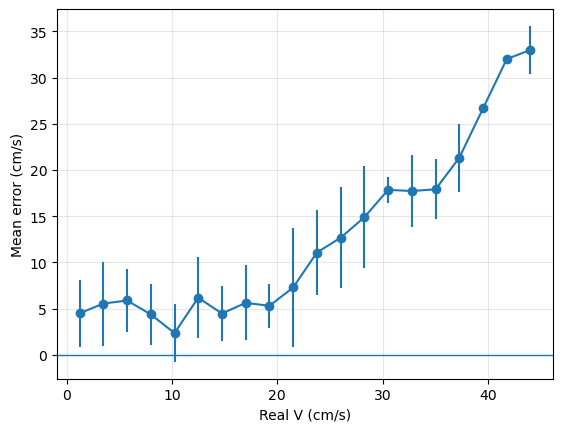

(array([ 1.2351918 ,  3.48798067,  5.74076954,  7.9935584 , 10.24634727,
        12.49913614, 14.751925  , 17.00471387, 19.25750274, 21.5102916 ,
        23.76308047, 26.01586934, 28.26865821, 30.52144707, 32.77423594,
        35.02702481, 37.27981367, 39.53260254, 41.78539141, 44.03818027]),
 array([ 4.47804573,  5.53456022,  5.86805788,  4.36416497,  2.33953562,
         6.17138566,  4.4566427 ,  5.61660113,  5.29013401,  7.28158088,
        11.06108631, 12.66598742, 14.88205362, 17.851534  , 17.72304009,
        17.90879657, 21.32811857, 26.6669216 , 32.01580669, 33.00291584]),
 array([3.59343621, 4.54425906, 3.43092811, 3.30495022, 3.12324021,
        4.41443866, 2.95388596, 4.04517301, 2.40299714, 6.42509699,
        4.59521267, 5.44356264, 5.50609081, 1.39304683, 3.86428523,
        3.24223285, 3.69741122,        nan,        nan, 2.59892581]),
 array([214,  76,  34,  36,  18,  14,  17,  22,  13,   7,   8,   9,   3,
          2,   2,   6,   3,   1,   1,   2]))

In [24]:
def binned_error(y_true, y_pred, n_bins=10):
    err = np.abs(y_pred - y_true)  # residual

    edges = np.linspace(y_true.min(), y_true.max(), n_bins + 1)
    bin_idx = np.digitize(y_true, edges) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    means, stds, mids, counts = [], [], [], []
    for b in range(n_bins):
        mask = bin_idx == b
        e = err[mask]
        counts.append(mask.sum())
        means.append(np.mean(e) if e.size else np.nan)
        stds.append(np.std(e, ddof=1) if e.size > 1 else np.nan)
        mids.append(0.5 * (edges[b] + edges[b+1]))

    plt.figure()
    plt.errorbar(mids, means, yerr=stds, fmt="o-")
    plt.axhline(0, linewidth=1)
    plt.xlabel("Real V (cm/s)")
    plt.ylabel("Mean error (cm/s)")
    plt.grid(True, alpha=0.3)
    plt.show()

    return np.array(mids), np.array(means), np.array(stds), np.array(counts)

binned_error(y_test , V_pred , n_bins=20)

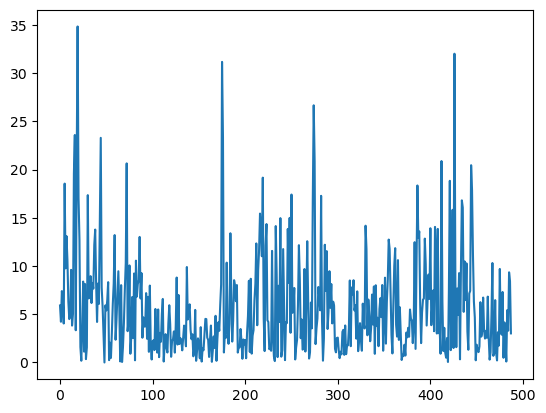

In [15]:
plt.plot(np.abs(V_pred - y_test))
# plt.plot(y_test)

Text(0, 0.5, 'pred speed (cm/s)')

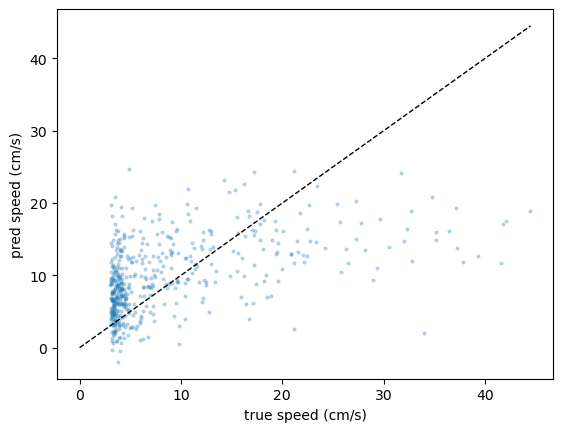

In [91]:
plt.scatter(y_test, V_pred , s=4, alpha=0.25) 
lims = [ 0, max(np.max(y_test), np.max(V_pred))] 
plt.plot(lims, lims, "k--" , lw=1) 
plt.xlabel("true speed (cm/s)") 
plt.ylabel("pred speed (cm/s)") 

# test regression for position corrolates

In [9]:
# 1. Align Position (x, y) to your time bins
# Assuming 'x_coords' and 'y_coords' are your original position arrays
X_pos = np.interp(t_bins, t, x) 
Y_pos = np.interp(t_bins, t, y)
# 2. Create Masks for the Spatial Split
# "Right side" is x > 0; "Left side" is x <= 0
right_mask = X_pos > 0
left_mask = ~right_mask # This is the "Left side"


V = np.interp(t_bins , t , v) #np.column_stack([vx, vy]) # Target Matrix (T x 2)

R = np.zeros((n_bins, n_cells))
for i, (cell_id, spike_times) in enumerate(spikes_by_cell.items()):
    counts, _ = np.histogram(spike_times, bins=np.append(t_bins, t_bins[-1] + dt))
    R[:, i] = scipy.ndimage.gaussian_filter1d(counts.astype(float), sigma=sigma_bins)

R_mean = np.mean(R, axis=0)
R_std = np.std(R, axis=0) + 1e-6 # Avoid division by zero
R_scaled = (R - R_mean) / R_std



# 3. Apply masks to Neural Data (R) and Velocity (V)
R_right = R_scaled[right_mask]
V_right = V[right_mask]

R_left = R_scaled[left_mask]
V_left = V[left_mask]

# 4. Train on Right, Test on Left
# We don't use train_test_split here because the spatial mask defines the split
model_spatial = LinearRegression()
model_spatial.fit(R_right, V_right)

# 5. Evaluate
V_pred_left = model_spatial.predict(R_left)
score_spatial = model_spatial.score(R_left, V_left)
rmse_spatial = np.sqrt(mean_squared_error(V_left, V_pred_left))

V_pred_right = model_spatial.predict(R_right)
score_spatial_train = model_spatial.score(R_right, V_right)
rmse_spatial_train = np.sqrt(mean_squared_error(V_right, V_pred_right))


print(f"Spatial Control (Train Right / Test Left)")
print(f"Test R^2 Score: {score_spatial:.4f}")
print(f"Test RMSE: {rmse_spatial:.4f}")


print(f"Predivtions for train (right)")
print(f"Test R^2 Score: {score_spatial_train:.4f}")
print(f"Train RMSE: {rmse_spatial_train:.4f}")




Spatial Control (Train Right / Test Left)
Test R^2 Score: -0.4201
Test RMSE: 9.1782
Predivtions for train (right)
Test R^2 Score: 0.5068
Train RMSE: 6.6180


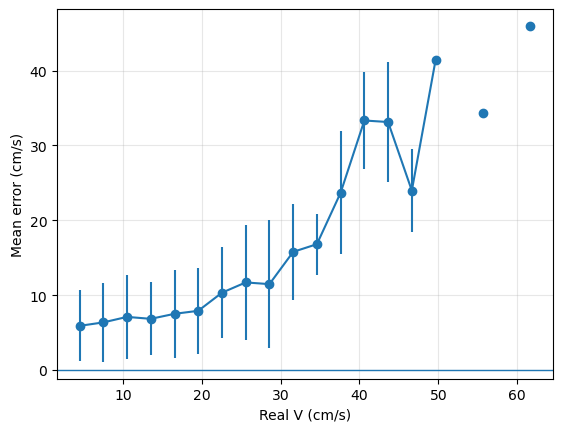

(array([ 4.51209398,  7.52087179, 10.52964959, 13.53842739, 16.5472052 ,
        19.555983  , 22.56476081, 25.57353861, 28.58231641, 31.59109422,
        34.59987202, 37.60864983, 40.61742763, 43.62620543, 46.63498324,
        49.64376104, 52.65253884, 55.66131665, 58.67009445, 61.67887226]),
 array([ 5.90697016,  6.36597164,  7.10256156,  6.84317401,  7.51318436,
         7.91409915, 10.33394059, 11.70456178, 11.47844731, 15.78712355,
        16.81234272, 23.68433838, 33.32956835, 33.12609436, 23.97259751,
        41.37571047,         nan, 34.31204507,         nan, 45.95931206]),
 array([4.75335334, 5.27665   , 5.65046829, 4.85415714, 5.9058671 ,
        5.7026942 , 6.0378496 , 7.6990073 , 8.51039793, 6.40981597,
        4.06600024, 8.2076777 , 6.44002913, 8.05445282, 5.48613528,
               nan,        nan,        nan,        nan,        nan]),
 array([962, 174,  99,  79,  59,  55,  41,  18,  20,   9,   9,  10,   4,
          3,   2,   1,   0,   1,   0,   1]))

In [10]:
def binned_error(y_true, y_pred, n_bins=10):
    err = np.abs(y_pred - y_true)  # residual

    edges = np.linspace(y_true.min(), y_true.max(), n_bins + 1)
    bin_idx = np.digitize(y_true, edges) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    means, stds, mids, counts = [], [], [], []
    for b in range(n_bins):
        mask = bin_idx == b
        e = err[mask]
        counts.append(mask.sum())
        means.append(np.mean(e) if e.size else np.nan)
        stds.append(np.std(e, ddof=1) if e.size > 1 else np.nan)
        mids.append(0.5 * (edges[b] + edges[b+1]))

    plt.figure()
    plt.errorbar(mids, means, yerr=stds, fmt="o-")
    plt.axhline(0, linewidth=1)
    plt.xlabel("Real V (cm/s)")
    plt.ylabel("Mean error (cm/s)")
    plt.grid(True, alpha=0.3)
    plt.show()

    return np.array(mids), np.array(means), np.array(stds), np.array(counts)

binned_error(V_left , V_pred_left , n_bins=20)

# 2

In [ ]:
def make_time_bins(t_s: np.ndarray, bin_size_s: float): 
    t_s = np.asarray(t_s, dtype=float).reshape(-1) 
    if t_s.size < 2: 
        raise ValueError("t_s must have at least 2 samples") 
    if not np.all(np.diff(t_s) > 0): 
        raise ValueError("t_s must be strictly increasing") 
    if bin_size_s <= 0: 
        raise ValueError("bin_size_s must be > 0") 
    
    edges = np.arange(t_s[0], t_s[-1] + bin_size_s, bin_size_s) 
    centers = 0.5 * (edges[:-1] + edges[1:]) 
    return edges, centers 
    
    
def bin_spike_counts(spikes_by_cell: dict, edges_s: np.ndarray): 
    cell_ids = sorted(spikes_by_cell.keys()) 
    counts = np.zeros((len(edges_s) - 1, len(cell_ids)), dtype=np.float32) 
    for j, cid in enumerate(cell_ids): 
        st = np.asarray(spikes_by_cell[cid], dtype=float) 
        st = st[np.isfinite(st)] 
        if st.size == 0: 
            continue 
        counts[:, j] = np.histogram(st, bins=edges_s)[0] 
    return counts, cell_ids 


def bin_mean(t_s: np.ndarray, values: np.ndarray, edges_s: np.ndarray): 
    t_s = np.asarray(t_s, dtype=float).reshape(-1) 
    values = np.asarray(values, dtype=float) 
    if t_s.shape[0] != values.shape[0]: 
        raise ValueError("values must have same length as t_s") 

    n_bins = len(edges_s) - 1 
    bin_idx = np.digitize(t_s, edges_s) - 1 
    keep = (bin_idx >= 0) & (bin_idx < n_bins) 

    bin_idx = bin_idx[keep] 
    denom = np.bincount(bin_idx, minlength=n_bins).astype(float) 
    denom = np.maximum(denom, 1.0) 
    
    if values.ndim == 1: 
        numer = np.bincount(bin_idx, weights=values[keep], minlength=n_bins).astype(float) 
        return numer / denom 

    if values.ndim == 2: 
        out = np.zeros((n_bins, values.shape[1]), dtype=float) 
        for k in range(values.shape[1]): 
            numer = np.bincount(bin_idx, weights=values[keep, k], minlength=n_bins).astype(float) 
            out[:, k] = numer / denom 
        return out 

    raise ValueError("values must be 1D or 2D") 

def zscore_fit(X: np.ndarray, eps: float = 1e-12): 
    mu = X.mean(axis=0) 
    sigma = X.std(axis=0) 
    sigma = np.where(sigma < eps, 1.0, sigma) 
    return mu, sigma 


def zscore_apply(X: np.ndarray, mu: np.ndarray, sigma: np.ndarray): 
    return (X - mu) / sigma 


def add_intercept(X: np.ndarray): 
    return np.concatenate([X, np.ones((X.shape[0], 1), dtype=X.dtype)], axis=1) 


def fit_ols(X: np.ndarray, Y: np.ndarray): 
    coef, *_ = np.linalg.lstsq(X, Y, rcond=None) 
    return coef 

def r2_score(y_true: np.ndarray, y_pred: np.ndarray): 
    y_true = np.asarray(y_true, dtype=float) 
    y_pred = np.asarray(y_pred, dtype=float) 
    y_pred = y_pred[:, None] 
    ss_res = np.sum((y_true - y_pred) ** 2, axis=0) 
    ss_tot = np.sum((y_true - y_true.mean(axis=0)) ** 2, axis=0) 
    return 1.0 - ss_res / ss_tot 

def corrcoef(y_true: np.ndarray, y_pred: np.ndarray): 
    y_true = np.asarray(y_true, dtype=float) 
    y_pred = np.asarray(y_pred, dtype=float) 
    if y_true.ndim == 1: 
        return float(np.corrcoef(y_true, y_pred)[0, 1]) 
    return np.array([ 
        np.corrcoef(y_true[:, k], y_pred[:, k])[0, 1] for k in range(y_true.shape[1]) 
    ])

In [8]:
# Parameters 
BIN_SIZE_S = 1        # bin width for spikes + velocity (seconds) 
TRAIN_FRAC = 0.7        # contiguous split 
SPEED_MIN = 3.0         # cm/s (match utils.RAT default filtering) 
SPEED_MAX = 100.0       # cm/s 
USE_RATE = True         # True: S(t)=Hz, False: S(t)=spike counts 

# Velocity from position at the native tracking rate (120 Hz) 
vx = np.gradient(x, t)  # cm/s 
vy = np.gradient(y, t)  # cm/s 
speed = np.sqrt(vx**2 + vy**2)  # cm/s 
    
# Bin everything into fixed-width time bins 
edges_s, t_bin = make_time_bins(t, BIN_SIZE_S) 
    
counts, cell_ids = bin_spike_counts(spikes_by_cell, edges_s) 
S = counts / BIN_SIZE_S if USE_RATE else counts 
    
vx_b    = bin_mean(t, vx, edges_s) 
vy_b    = bin_mean(t, vy, edges_s) 
speed_b = bin_mean(t, speed, edges_s) 

# Filter out very slow / very fast bins (optional) 
keep = ( 
    np.isfinite(speed_b) 
    & (speed_b >= SPEED_MIN) 
    & (speed_b <= SPEED_MAX) 
) 
    
S = S[keep] 
vx_b = vx_b[keep] 
vy_b = vy_b[keep] 
speed_b = speed_b[keep] 
t_bin = t_bin[keep] 
    
n = len(t_bin) 
split = int(TRAIN_FRAC * n) 
print(f"n_bins={n}  n_train={split}  n_test={n - split}  n_features={S.shape[1]}") 
    
# Standardize features using train stats only 
mu, sigma = zscore_fit(S[:split]) 
S_train = zscore_apply(S[:split], mu, sigma) 
S_test = zscore_apply(S[split:], mu, sigma) 
    
X_train = add_intercept(S_train) 
X_test = add_intercept(S_test) 
    
# Targets 
V_train = np.column_stack([vx_b[:split], vy_b[:split]]) 
V_test = np.column_stack([vx_b[split:], vy_b[split:]]) 
speed_train = speed_b[:split] 
speed_test = speed_b[split:] 
    
# Fit linear regression: V = A S + b 
A_v = fit_ols(X_train, V_train)          # (n_features+1, 2) 
a_speed = fit_ols(X_train, speed_train)  # (n_features+1,) 

# (Optional) Convert back to raw-feature form: speed ≈ a·S + b 
w_speed = a_speed[:-1] 
b_speed = float(a_speed[-1]) 
a_speed_raw = w_speed / sigma 
b_speed_raw = b_speed - (mu / sigma) @ w_speed 
    
top = np.argsort(np.abs(a_speed_raw))[::-1][:10] 
print(f"Speed model (raw features): b={b_speed_raw:.3f}") 
print("Top |a| cells (cell_id, a):", [(cell_ids[i], float(a_speed_raw[i])) for i in top]) 
    
# Predict 
V_hat = X_test @ A_v 
speed_hat_direct = X_test @ a_speed 
speed_hat_from_v = np.linalg.norm(V_hat, axis=1) 
    
# Metrics 
r2_v = r2_score(V_test, V_hat) 
r2_speed_direct = float(r2_score(speed_test, speed_hat_direct)[0]) 
r2_speed_from_v = float(r2_score(speed_test, speed_hat_from_v)[0]) 
    
print("Test R²:  " , (r2_v[0], r2_v[1])) 
print("Test R² (speed): direct=%.3f  from_v=%.3f" % (r2_speed_direct, r2_speed_from_v)) 
print("Test corr (speed): direct=%.3f  from_v=%.3f" % ( 
    corrcoef(speed_test, speed_hat_direct), 
    corrcoef(speed_test, speed_hat_from_v) ))

n_bins=1183  n_train=828  n_test=355  n_features=205
Speed model (raw features): b=-1.046
Top |a| cells (cell_id, a): [(1116, 0.3843747711428424), (560, 0.36241722358295814), (516, -0.349090097565579), (633, 0.33728140028798453), (849, -0.31723687012153584), (409, -0.2897763533534183), (1003, 0.2885718006941162), (806, 0.27699218172458173), (780, -0.27155208536398173), (617, -0.26332793116522174)]
Test R²:   (array([ 0.26610775, -1.74364037]), array([ 0.19908507, -0.53996126]))
Test R² (speed): direct=-0.028  from_v=-0.969
Test corr (speed): direct=0.512  from_v=-0.009


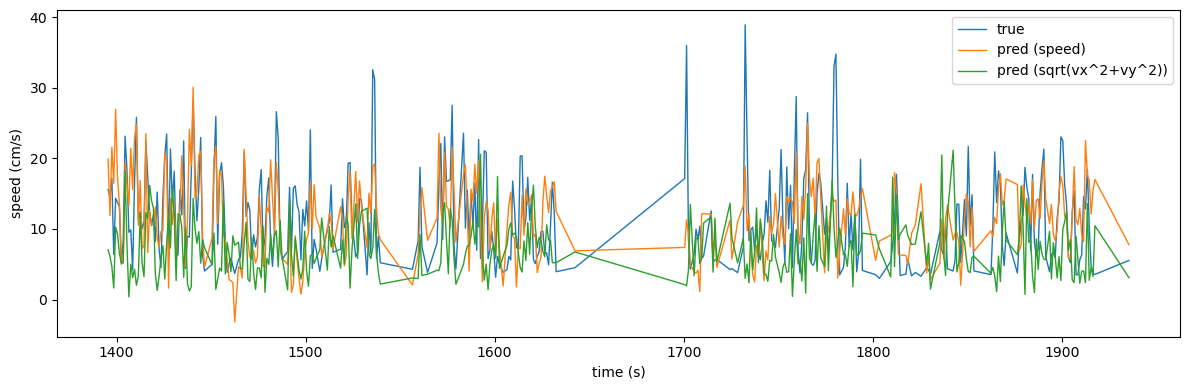

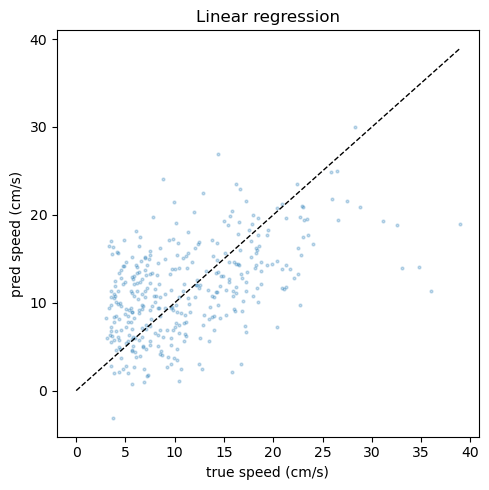

In [9]:

# Plots (test segment) 
t_test = t_bin[split:] 
    
plt.figure(figsize=(12, 4)) 
plt.plot(t_test, speed_test, lw=1, label="true") 
plt.plot(t_test, speed_hat_direct, lw=1, label="pred (speed)") 
plt.plot(t_test, speed_hat_from_v, lw=1, label="pred (sqrt(vx^2+vy^2))") 
plt.xlabel("time (s)") 
plt.ylabel("speed (cm/s)") 
plt.legend() 
plt.tight_layout() 
    
plt.figure(figsize=(5, 5)) 
plt.scatter(speed_test, speed_hat_direct, s=4, alpha=0.25) 
lims = [0, max(np.max(speed_test), np.max(speed_hat_direct))] 
plt.plot(lims, lims, "k--" , lw=1) 
plt.xlabel("true speed (cm/s)") 
plt.ylabel("pred speed (cm/s)") 
plt.title("Linear regression") 
plt.tight_layout()


# MLE

In [2]:
# Load one session 
RAT_ID = 2 
LIGHTING = "light"  
     
rat = RAT(n=RAT_ID, lighting=LIGHTING, filter_speed=True) 

t = rat.T  # (s), starts at 0 
x = rat.X  # (cm) 
y = rat.Y  # (cm) 
v = rat.V # (cm/s)
    
# Choose which spikes to use 
spikes_by_cell = {} 
spikes_by_cell.update(rat.grid_mod1) 
spikes_by_cell.update(rat.grid_mod2) 
spikes_by_cell.update(rat.grid_mod3) 
    
print(f"duration_s={t[-1]:.1f}  n_cells={len(spikes_by_cell)}")


duration_s=1945.8  n_cells=205


## vx , vy

In [56]:
import numpy as np
import scipy.ndimage

# --- 1. Parameters & Preprocessing ---
dt = 0.05  # 50ms bins for decoding
v_bins = np.linspace(-40, 40, 20)  # 2D grid for vx and vy
t_bins = np.arange(t[0], t[-1], dt)

# Calculate ground truth velocity components
vx_true = np.gradient(x, t)
vy_true = np.gradient(y, t)

# Interp velocity to match our decoding time bins
vx_target = np.interp(t_bins, t, vx_true)
vy_target = np.interp(t_bins, t, vy_true)

# --- 2. Build Velocity Tuning Curves (The "Model") ---
# We'll use the first 80% of data to build tuning curves
split_idx = int(0.8 * len(t_bins))
tuning_curves = {}

for cell_id, spike_times in spikes_by_cell.items():
    # Get spike counts in our time bins
    counts, _ = np.histogram(spike_times, bins=np.append(t_bins, t_bins[-1]+dt))
    
    # Calculate Mean Firing Rate per Velocity Bin
    # We use the training portion to avoid circularity
    h_spikes, _, _ = np.histogram2d(vx_target[:split_idx], vy_target[:split_idx], 
                                    bins=[v_bins, v_bins], weights=counts[:split_idx])
    h_occupancy, _, _ = np.histogram2d(vx_target[:split_idx], vy_target[:split_idx], 
                                       bins=[v_bins, v_bins])
    
    # Firing Rate = Spikes / Time spent in bin
    rate_map = h_spikes / (h_occupancy * dt + 1e-9)
    # Smooth the tuning curve to fill in gaps
    tuning_curves[cell_id] = scipy.ndimage.gaussian_filter(rate_map, sigma=1.0)

# --- 3. Maximum Likelihood Estimation (Decoding) ---
# Flatten the velocity grid for easier calculation
VX, VY = np.meshgrid((v_bins[:-1] + v_bins[1:])/2, (v_bins[:-1] + v_bins[1:])/2)
vx_flat = VX.flatten()
vy_flat = VY.flatten()

# Pre-calculate tuning curve values for all cells into a [N_cells x N_v_bins] matrix
TC_matrix = np.array([tuning_curves[cid].flatten() for cid in spikes_by_cell.keys()])

def decode_mle(spike_counts):
    """
    Finds the velocity that maximizes: 
    Sum [ n_i * log(lambda_i) - lambda_i * dt ]
    """
    # spike_counts is [N_cells, 1]
    # TC_matrix is [N_cells, N_velocity_bins]
    
    # Log-Likelihood calculation
    # We add a small constant to log to avoid log(0)
    term1 = spike_counts @ np.log(TC_matrix + 1e-3) 
    term2 = np.sum(TC_matrix * dt, axis=0)
    
    log_likelihood = term1 - term2
    
    # Find index of maximum likelihood
    best_bin_idx = np.argmax(log_likelihood)
    return vx_flat[best_bin_idx], vy_flat[best_bin_idx]

# --- 4. Run Decoder on Test Data ---
test_counts = []
for cell_id, spike_times in spikes_by_cell.items():
    c, _ = np.histogram(spike_times, bins=np.append(t_bins, t_bins[-1]+dt))
    test_counts.append(c)
test_counts = np.array(test_counts).T # Dimensions: [Time x Cells]

predictions = []
for i in range(split_idx, len(t_bins)):
    v_est = decode_mle(test_counts[i, :])
    predictions.append(v_est)

predictions = np.array(predictions)

Decoder RMSE: 26.71 cm/s


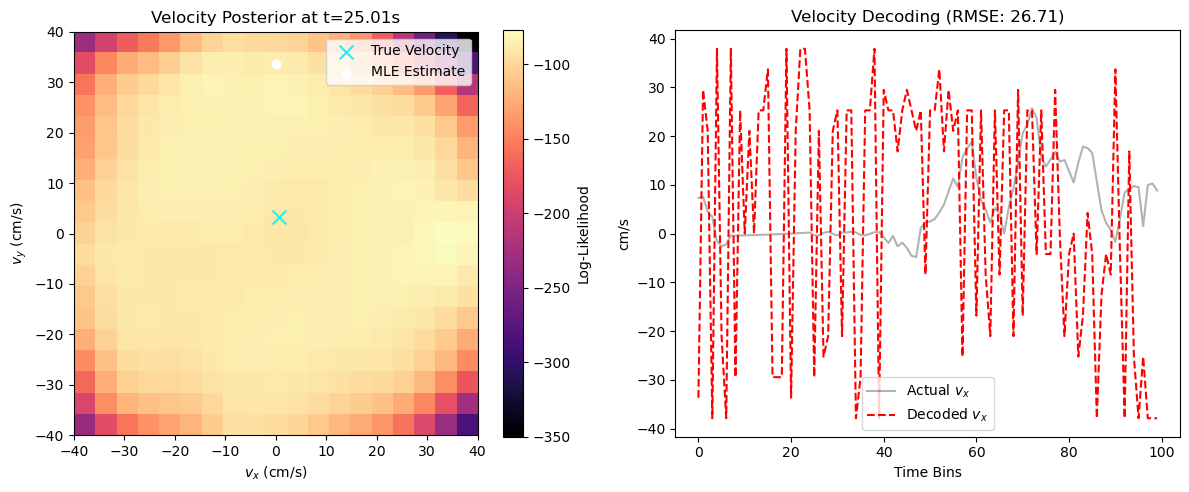

In [57]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error


bin_centers = (v_bins[:-1] + v_bins[1:]) / 2
# Combine vx and vy into a single matrix for the test period
gt_test = np.column_stack([vx_target[split_idx:], vy_target[split_idx:]])

# --- 1. Calculate Log-Likelihood for a specific bin (e.g., bin 500) ---
# idx = 500 
# counts_at_t = test_counts[idx, :]

rel_idx = 500
global_idx = split_idx + rel_idx
counts_at_t = test_counts[global_idx, :]


# log L(v) = sum( n_i * log(rate_i * dt) - rate_i * dt )
log_lik = counts_at_t @ np.log(TC_matrix * dt + 1e-6) - np.sum(TC_matrix * dt, axis=0)
log_lik_grid = log_lik.reshape(len(bin_centers), len(bin_centers))

# --- 2. Calculate RMSE ---
# test_preds contains the (vx, vy) of the maximum bin for every test time step
rmse = np.sqrt(mean_squared_error(gt_test, predictions))
print(f"Decoder RMSE: {rmse:.2f} cm/s")

# --- 3. Plotting ---
plt.figure(figsize=(12, 5))

# Heatmap of the Likelihood
plt.subplot(1, 2, 1)
plt.imshow(log_lik_grid.T, origin='lower', extent=[-40, 40, -40, 40], cmap='magma')
plt.colorbar(label='Log-Likelihood')
# plt.scatter(vx_target[idx], vy_target[idx], color='cyan', marker='x', s=100, label='True Velocity')
# plt.scatter(predictions[idx-split_idx, 0], predictions[idx-split_idx, 1], color='white', marker='o', label='MLE Estimate')
plt.scatter(vx_target[global_idx], vy_target[global_idx], 
            color='cyan', marker='x', s=100, label='True Velocity')

plt.scatter(predictions[rel_idx, 0], predictions[rel_idx, 1], 
            color='white', marker='o', label='MLE Estimate')

plt.title(f'Velocity Posterior at t={t_bins[rel_idx]:.2f}s')
plt.xlabel('$v_x$ (cm/s)')
plt.ylabel('$v_y$ (cm/s)')
plt.legend()

# Ground Truth vs Prediction Trace
plt.subplot(1, 2, 2)
plt.plot(gt_test[:100, 0], color='black', alpha=0.3, label='Actual $v_x$')
plt.plot(predictions[:100, 0], color='red', linestyle='--', label='Decoded $v_x$')
plt.title(f'Velocity Decoding (RMSE: {rmse:.2f})')
plt.xlabel('Time Bins')
plt.ylabel('cm/s')
plt.legend()

plt.tight_layout()
plt.show()

In [53]:
np.linspace(0, max(v), 30) 


array([ 0.        ,  3.40385794,  6.80771589, 10.21157383, 13.61543177,
       17.01928972, 20.42314766, 23.8270056 , 27.23086355, 30.63472149,
       34.03857943, 37.44243738, 40.84629532, 44.25015326, 47.65401121,
       51.05786915, 54.46172709, 57.86558504, 61.26944298, 64.67330092,
       68.07715887, 71.48101681, 74.88487475, 78.2887327 , 81.69259064,
       85.09644858, 88.50030653, 91.90416447, 95.30802241, 98.71188036])

## V

Scalar Speed RMSE: 20.30 cm/s


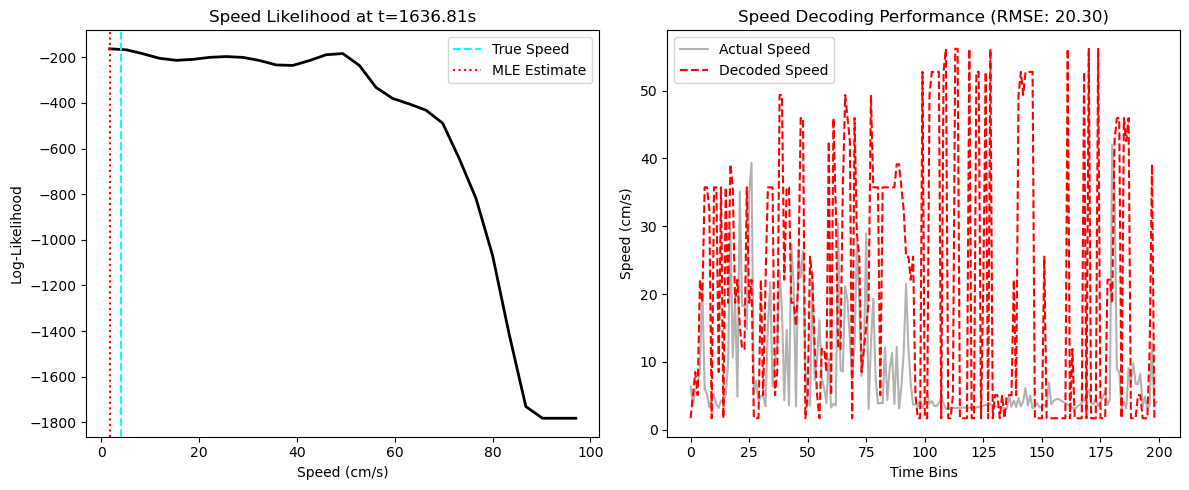

In [ ]:
# --- 1. Parameters & Preprocessing ---
dt = 0.8
# Define 1D speed bins (Speed is always positive)
speed_bins = np.linspace(0, max(v), 30) 
t_bins = np.arange(t[0], t[-1], dt)

# Calculate scalar speed from components
vx_true = np.gradient(x, t)
vy_true = np.gradient(y, t)
v_scalar_true = v

# Interp speed to match our decoding time bins
v_target = np.interp(t_bins, t, v_scalar_true)

# --- 2. Build 1D Speed Tuning Curves ---
split_idx = int(0.8 * len(t_bins))
tuning_curves_1d = {}

for cell_id, spike_times in spikes_by_cell.items():
    counts, _ = np.histogram(spike_times, bins=np.append(t_bins, t_bins[-1]+dt))
    
    # Calculate Mean Firing Rate per Speed Bin
    h_spikes, _    = np.histogram(v_target[:split_idx], bins=speed_bins, weights=counts[:split_idx])
    h_occupancy, _ = np.histogram(v_target[:split_idx], bins=speed_bins)
    
    rate_map = h_spikes / (h_occupancy * dt + 1e-9)
    # Smooth the 1D tuning curve
    tuning_curves_1d[cell_id] = scipy.ndimage.gaussian_filter1d(rate_map, sigma=1.0)

# --- 3. MLE Decoding (Scalar Speed) ---
speed_centers = (speed_bins[:-1] + speed_bins[1:]) / 2
TC_matrix_1d = np.array([tuning_curves_1d[cid] for cid in spikes_by_cell.keys()])

def decode_speed_mle(spike_counts):
    # Log-Likelihood for 1D speed
    term1 = spike_counts @ np.log(TC_matrix_1d * dt + 1e-3) 
    term2 = np.sum(TC_matrix_1d * dt, axis=0)
    log_likelihood = term1 - term2
    
    best_bin_idx = np.argmax(log_likelihood)
    return speed_centers[best_bin_idx], log_likelihood

# --- 4. Run Decoder on Test Data ---
test_counts = []
for cell_id, spike_times in spikes_by_cell.items():
    c, _ = np.histogram(spike_times, bins=np.append(t_bins, t_bins[-1]+dt))
    test_counts.append(c)
test_counts = np.array(test_counts).T 

predictions_speed = []
for i in range(split_idx, len(t_bins)):
    s_est, _ = decode_speed_mle(test_counts[i, :])
    predictions_speed.append(s_est)

predictions_speed = np.array(predictions_speed)
gt_test_speed = v_target[split_idx:]

# --- 5. Visualization & Error ---
rel_idx = 100
global_idx = split_idx + rel_idx
_, log_lik_1d = decode_speed_mle(test_counts[global_idx, :])

rmse = np.sqrt(mean_squared_error(gt_test_speed, predictions_speed))
print(f"Scalar Speed RMSE: {rmse:.2f} cm/s")

plt.figure(figsize=(12, 5))

# 1D Log-Likelihood Plot
plt.subplot(1, 2, 1)
plt.plot(speed_centers, log_lik_1d, color='black', lw=2)
plt.axvline(v_target[global_idx], color='cyan', linestyle='--', label='True Speed')
plt.axvline(predictions_speed[rel_idx], color='red', linestyle=':', label='MLE Estimate')
plt.title(f'Speed Likelihood at t={t_bins[global_idx]:.2f}s')
plt.xlabel('Speed (cm/s)')
plt.ylabel('Log-Likelihood')
plt.legend()

# Speed Trace
plt.subplot(1, 2, 2)
plt.plot(gt_test_speed[:200], color='black', alpha=0.3, label='Actual Speed')
plt.plot(predictions_speed[:200], color='red', linestyle='--', label='Decoded Speed')
plt.title(f'Speed Decoding Performance (RMSE: {rmse:.2f})')
plt.xlabel('Time Bins')
plt.ylabel('Speed (cm/s)')
plt.legend()

plt.tight_layout()
plt.show()

Text(0, 0.5, 'pred speed (cm/s)')

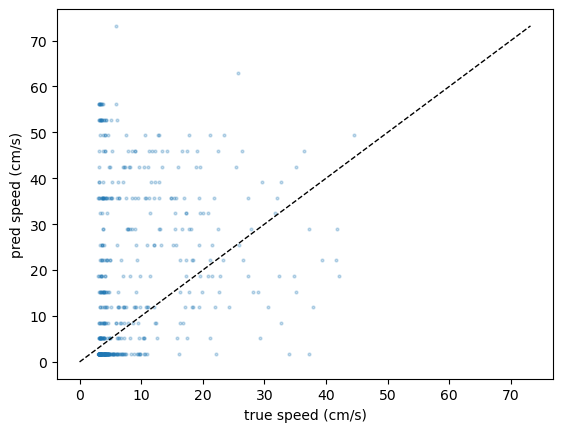

In [18]:
plt.scatter(gt_test_speed, predictions_speed , s=4, alpha=0.25) 
lims = [ 0, max(np.max(gt_test_speed), np.max(predictions_speed))] 
plt.plot(lims, lims, "k--" , lw=1) 
plt.xlabel("true speed (cm/s)") 
plt.ylabel("pred speed (cm/s)") 

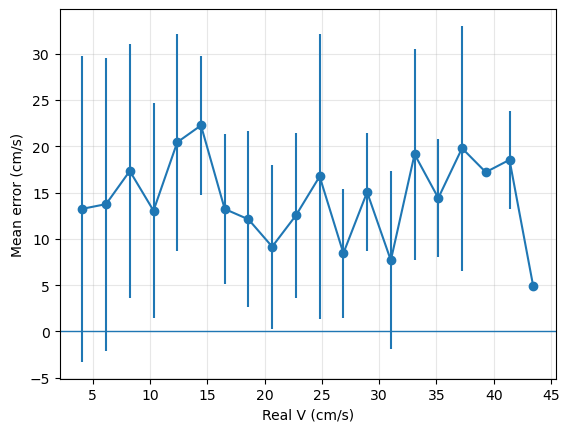

(array([ 4.08235875,  6.15405473,  8.22575071, 10.29744668, 12.36914266,
        14.44083864, 16.51253461, 18.58423059, 20.65592657, 22.72762254,
        24.79931852, 26.8710145 , 28.94271047, 31.01440645, 33.08610243,
        35.1577984 , 37.22949438, 39.30119036, 41.37288633, 43.44458231]),
 array([13.24990266, 13.75561508, 17.33791633, 13.0487229 , 20.44166268,
        22.26420183, 13.23072842, 12.11263767,  9.15709766, 12.53703326,
        16.74856776,  8.44832007, 15.05030564,  7.68051372, 19.14703749,
        14.415644  , 19.79871205, 17.20934506, 18.5434007 ,  4.87550988]),
 array([16.54642654, 15.83408701, 13.71400887, 11.61088587, 11.71856534,
         7.55177462,  8.10929581,  9.49543399,  8.86021527,  8.89732799,
        15.41668526,  6.9666096 ,  6.38843695,  9.60616894, 11.39090277,
         6.36850153, 13.21643568,         nan,  5.3062561 ,         nan]),
 array([257,  51,  37,  27,  22,   6,  21,  16,   9,   9,   4,   5,   4,
          3,   4,   3,   4,   1,   3,   1]))

In [22]:
binned_error(gt_test_speed , predictions_speed , n_bins=20)

In [ ]:
# --- 1. Compute the Priors ---

# 1.1 Empirical Prior: From training data distribution
# We use the same bins as the tuning curves
prior_counts, _ = np.histogram(v_target[:split_idx], bins=speed_bins)
prior_empirical = prior_counts / np.sum(prior_counts)
log_prior_empirical = np.log(prior_empirical + 1e-6) # Add small epsilon to avoid log(0)

# 1.2 Gaussian Prior: Centered at training mean speed
mean_speed = np.mean(v_target[:split_idx])
std_speed = np.std(v_target[:split_idx])
prior_gaussian = scipy.stats.norm.pdf(speed_centers, loc=mean_speed, scale=std_speed)
log_prior_gaussian = np.log(prior_gaussian / np.sum(prior_gaussian) + 1e-6)


# --- 2. MAP Decoding Function ---

def decode_speed_map(spike_counts, log_prior_type='empirical'):
    # Select which prior to use
    if log_prior_type == 'empirical':
        lp = log_prior_empirical
    elif log_prior_type == 'gaussian':
        lp = log_prior_gaussian
    else:
        lp = 0 # Becomes MLE
        
    # Log-Likelihood (from your previous code)
    term1 = spike_counts @ np.log(TC_matrix_1d * dt + 1e-3) 
    term2 = np.sum(TC_matrix_1d * dt, axis=0)
    log_likelihood = term1 - term2
    
    # Calculate Posterior
    log_posterior = log_likelihood + lp
    
    best_bin_idx = np.argmax(log_posterior)
    return speed_centers[best_bin_idx], log_posterior


# --- 3. Run Decoder and Compare ---

preds_mle = []
preds_map_emp = []
preds_map_gauss = []

for i in range(split_idx, len(t_bins)):
    # MLE
    s_mle, _ = decode_speed_map(test_counts[i, :], log_prior_type='none')
    preds_mle.append(s_mle)
    
    # MAP Empirical
    s_emp, _ = decode_speed_map(test_counts[i, :], log_prior_type='empirical')
    preds_map_emp.append(s_emp)

preds_mle = np.array(preds_mle)
preds_map_emp = np.array(preds_map_emp)

# Calculate RMSE for both
rmse_mle = np.sqrt(mean_squared_error(gt_test_speed, preds_mle))
rmse_emp = np.sqrt(mean_squared_error(gt_test_speed, preds_map_emp))

print(f"MLE RMSE no prior: {rmse_mle:.2f} | MAP Empirical prior RMSE: {rmse_emp:.2f}")

MLE RMSE: 20.30 | MAP Empirical RMSE: 19.41


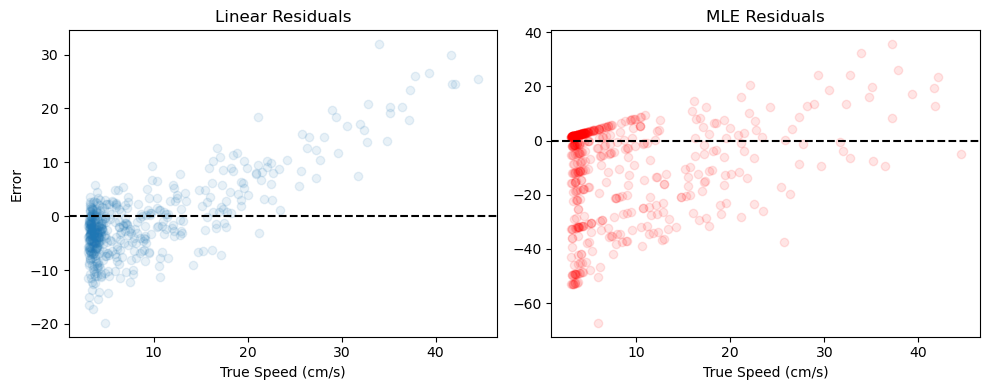

In [94]:

# Calculate residuals
res_linear = y_test - V_pred
res_mle = gt_test_speed - predictions_speed

plt.figure(figsize=(10, 4))

# Plot Residuals vs True Speed
plt.subplot(1, 2, 1)
plt.scatter(y_test, res_linear, alpha=0.1, label='Linear')
plt.axhline(0, color='k', linestyle='--')
plt.title('Linear Residuals')
plt.xlabel('True Speed (cm/s)')
plt.ylabel('Error')

plt.subplot(1, 2, 2)
plt.scatter(gt_test_speed, res_mle, alpha=0.1, color='red', label='MLE')
plt.axhline(0, color='k', linestyle='--')
plt.title('MLE Residuals')
plt.xlabel('True Speed (cm/s)')

plt.tight_layout()
plt.show()

# Fano Factor

In [9]:
def longest_constant_run_tol(V, atol=1e-8, rtol=0.0):
    V = np.asarray(V)
    if V.size == 0:
        return 0, None, None

    same_as_prev = np.isclose(V[1:], V[:-1], atol=atol, rtol=rtol)
    change = np.r_[True, ~same_as_prev, True]
    idx = np.flatnonzero(change)
    lengths = np.diff(idx)
    k = lengths.argmax()

    start = idx[k]
    end = idx[k+1] - 1
    return lengths[k], start, end

l , a ,b =longest_constant_run_tol(v , atol= 2)

In [77]:
def longest_constant_run_tol(V, atol=1e-8, rtol=0.0, vmin=3, vmax=100):
    V = np.asarray(V)
    if V.size == 0:
        return 0, None, None

    # Two neighboring points belong to the same run only if:
    # 1) they are close enough to be considered equal
    # 2) both are within the allowed speed range
    in_range = (V >= vmin) & (V <= vmax)
    same_as_prev = np.isclose(V[1:], V[:-1], atol=atol, rtol=rtol)
    same_run = same_as_prev & in_range[1:] & in_range[:-1]

    change = np.r_[True, ~same_run, True]
    idx = np.flatnonzero(change)
    lengths = np.diff(idx)

    # Keep only runs whose first element is in range
    valid_runs = in_range[idx[:-1]]
    if not np.any(valid_runs):
        return 0, None, None

    lengths_valid = lengths.copy()
    lengths_valid[~valid_runs] = -1

    k = lengths_valid.argmax()
    start = idx[k]
    end = idx[k + 1] - 1
    return lengths[k], start, end
l , a , b = longest_constant_run_tol(v , atol = 10 , vmin= 3 , vmax= 100)

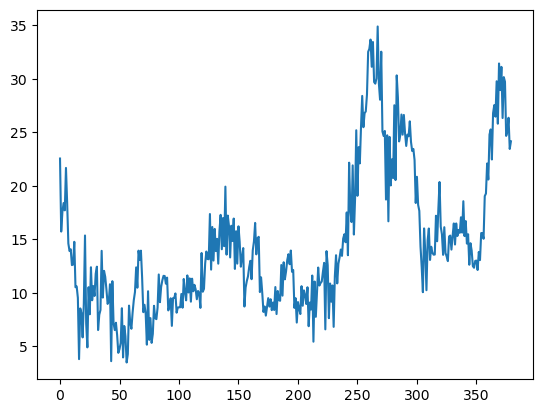

In [78]:
plt.plot(v[a:b])

In [30]:
def find_k(array , value):
        """Finds index of the closest value in an array."""
        return (np.abs(array-value)).argmin()


In [79]:
delta_t  = t[a:b]
spikes_ind =[find_k(delta_t, i) for i in spikes_by_cell[644] if  find_k(delta_t, i) >0]


In [80]:
ff = np.mean(spikes_ind) / np.var(spikes_ind)
ff

np.float64(39.34818260619577)

### Let's use binned speed 

In [ ]:
# --- 1. Parameters & Preprocessing ---
dt = 0.8
# Define 1D speed bins (Speed is always positive)
speed_bins = np.linspace(0, max(v), 30) 
t_bins = np.arange(t[0], t[-1], dt)

# Calculate scalar speed from components
vx_true = np.gradient(x, t)
vy_true = np.gradient(y, t)
v_scalar_true = v

# Interp speed to match our decoding time bins
v_target = np.interp(t_bins, t, v_scalar_true)

# --- 2. Build 1D Speed Tuning Curves ---
split_idx = int(0.8 * len(t_bins))
v_binned_ = {}

for cell_id, spike_times in spikes_by_cell.items():
    counts, _ = np.histogram(spike_times, bins=np.append(t_bins, t_bins[-1]+dt))
    
    # Calculate Mean Firing Rate per Speed Bin
    v_binned_[cell_id], _    = np.histogram(v_target[:split_idx], bins=speed_bins, weights=counts[:split_idx])
    
    

In [ ]:
# Dictionary to store the list of spike counts per speed bin for each cell
v_binned_counts = {} 

# 1. Digitize the target speed into the defined bins
# this tells us which bin index each time point belongs to
speed_indices = np.digitize(v_target, speed_bins) - 1

for cell_id, spike_times in spikes_by_cell.items():
    # Calculate spike counts in each decoding time bin (dt = 0.8)
    counts, _ = np.histogram(spike_times, bins=np.append(t_bins, t_bins[-1]+dt))
    
    # We only use the training portion (first 80%) as per your split_idx
    train_counts = counts[:split_idx]
    train_speed_idx = speed_indices[:split_idx]
    
    # Initialize a list for each speed bin for this specific cell
    v_binned_counts[cell_id] = [[] for _ in range(len(speed_bins))]
    
    # Group the spike counts by their corresponding speed bin
    for i in range(len(train_counts)):
        idx = train_speed_idx[i]
        # Ensure index is within valid range of speed_bins
        if 0 <= idx < len(speed_bins):
            v_binned_counts[cell_id][idx].append(train_counts[i])

# --- 3. Calculate Mean (Tuning Curve) and Fano Factor ---
tuning_curves = {}
fano_factors = {}

for cell_id, bins_list in v_binned_counts.items():
    # Calculate mean and variance for each speed bin
    means = np.array([np.mean(b) if len(b) > 0 else 0 for b in bins_list])
    vars  = np.array([np.var(b) if len(b) > 0 else 0 for b in bins_list])
    
    tuning_curves[cell_id] = means
    # Calculate Fano Factor (Var/Mean), avoiding division by zero
    fano_factors[cell_id] = np.divide(vars, means, out=np.zeros_like(vars), where=means!=0)

In [33]:
len(v_binned_counts[644])

30

In [26]:
fano_factors

{644: array([3.10426777, 4.57150879, 6.15185745, 4.4450114 , 4.95859649,
        4.69328753, 4.8510296 , 4.97832435, 5.37516869, 1.37142857,
        3.55925156, 3.41666667, 5.81292517, 1.        , 3.2       ,
        1.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ]),
 695: array([2.41301532, 3.76507478, 4.18434199, 5.35080234, 3.73702452,
        5.05915587, 4.13209829, 2.88700234, 4.74042063, 4.40952381,
        2.70850202, 1.74603175, 1.83333333, 2.45833333, 1.78571429,
        2.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ]),
 711: array([ 5.73783186,  9.82022746,  8.8950885 , 12.97437956,  9.64142056,
        11.22021116,  9.34771334,  6.4538961 ,  5.10391363,  3.93995859,
        13.51384615

# possion assumption on position


In [3]:
from utils import RAT

# Load one session 
RAT_ID = 2 
LIGHTING = "light"  
     
rat = RAT(n=RAT_ID, lighting=LIGHTING, filter_speed=False) 

t = rat.T  # (s), starts at 0 
x = rat.X  # (cm) 
y = rat.Y  # (cm) 
v = rat.V  # (cm/s)
    
# Choose which spikes to use 
spikes_by_cell = {} 
spikes_by_cell.update(rat.grid_mod1) 
spikes_by_cell.update(rat.grid_mod2) 
spikes_by_cell.update(rat.grid_mod3) 
    
print(f"duration_s={t[-1]:.1f}  n_cells={len(spikes_by_cell)}")


duration_s=1951.0  n_cells=205


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def bin_spike_counts(spike_times, t, dt):
    """
    Count spikes in consecutive time bins spanning [t[0], t[-1]].

    Parameters
    ----------
    spike_times : array-like
        Spike timestamps in seconds for one cell.
    t : array-like
        Behavioral timestamps in seconds.
    dt : float
        Time bin size in seconds.

    Returns
    -------
    edges : np.ndarray
        Time bin edges, shape (n_bins + 1,)
    counts : np.ndarray
        Spike counts per time bin, shape (n_bins,)
    centers : np.ndarray
        Time bin centers, shape (n_bins,)
    """
    spike_times = np.asarray(spike_times)
    t0, t1 = t[0], t[-1]

    edges = np.arange(t0, t1 + dt, dt)
    counts, _ = np.histogram(spike_times, bins=edges)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return edges, counts, centers

def interpolate_behavior_to_bins(t, x, y, v, centers):
    """
    Interpolate behavioral variables to time-bin centers.
    """
    x_bin = np.interp(centers, t, x)
    y_bin = np.interp(centers, t, y)
    v_bin = np.interp(centers, t, v)
    return x_bin, y_bin, v_bin

def assign_position_bins(x_bin, y_bin, x_edges, y_edges):
    """
    Assign each (x, y) sample to a 2D spatial bin.

    Returns
    -------
    xb : np.ndarray
        x-bin index for each sample
    yb : np.ndarray
        y-bin index for each sample
    valid : np.ndarray of bool
        True where sample falls inside the bin ranges
    """
    xb = np.digitize(x_bin, x_edges) - 1
    yb = np.digitize(y_bin, y_edges) - 1

    valid = (
        (xb >= 0) & (xb < len(x_edges) - 1) &
        (yb >= 0) & (yb < len(y_edges) - 1)
    )
    return xb, yb, valid




def spatial_fano_factor_for_cell(
    spike_times, t, x, y, v,
    dt=0.1,
    x_edges=None,
    y_edges=None,
    min_samples_per_bin=20,
    speed_threshold=None
):
    """
    Compute Fano factor of spike counts conditional on spatial bin.

    Parameters
    ----------
    spike_times : array-like
        Spike times for one cell.
    t, x, y, v : np.ndarray
        Behavioral time, x-position, y-position, speed.
    dt : float
        Time bin size in seconds.
    x_edges, y_edges : np.ndarray or None
        Spatial bin edges. If None, they are chosen automatically.
    min_samples_per_bin : int
        Minimum number of time bins in a spatial bin to compute Fano.
    speed_threshold : float or None
        If provided, only include time bins with v >= speed_threshold.

    Returns
    -------
    result : dict
        Contains Fano map, mean map, var map, occupancy counts, etc.
    """
    # 1) Time-binned spike counts
    _, counts, centers = bin_spike_counts(spike_times, t, dt)

    # 2) Behavior at time-bin centers
    x_bin, y_bin, v_bin = interpolate_behavior_to_bins(t, x, y, v, centers)

    # 3) Optional speed filtering
    mask = np.ones_like(counts, dtype=bool)
    if speed_threshold is not None:
        mask &= (v_bin >= speed_threshold)

    counts = counts[mask]
    x_bin = x_bin[mask]
    y_bin = y_bin[mask]

    # 4) Spatial bin edges
    if x_edges is None:
        x_edges = np.linspace(np.nanmin(x), np.nanmax(x), 21)  # 20 x-bins
    if y_edges is None:
        y_edges = np.linspace(np.nanmin(y), np.nanmax(y), 21)  # 20 y-bins

    xb, yb, valid = assign_position_bins(x_bin, y_bin, x_edges, y_edges)

    counts = counts[valid]
    xb = xb[valid]
    yb = yb[valid]

    nx = len(x_edges) - 1
    ny = len(y_edges) - 1

    mean_map = np.full((ny, nx), np.nan)
    var_map  = np.full((ny, nx), np.nan)
    fano_map = np.full((ny, nx), np.nan)
    occ_map  = np.zeros((ny, nx), dtype=int)

    # 5) Collect counts for each spatial bin
    for ix in range(nx):
        for iy in range(ny):
            idx = (xb == ix) & (yb == iy)
            n = np.sum(idx)
            occ_map[iy, ix] = n

            if n < min_samples_per_bin:
                continue

            c = counts[idx]
            mu = np.mean(c)

            # use sample variance (ddof=1) if enough samples
            var = np.var(c, ddof=1) if n > 1 else np.nan

            mean_map[iy, ix] = mu
            var_map[iy, ix] = var

            if mu > 0:
                fano_map[iy, ix] = var / mu

    return {
        "fano_map": fano_map,
        "mean_map": mean_map,
        "var_map": var_map,
        "occ_map": occ_map,
        "x_edges": x_edges,
        "y_edges": y_edges,
        "dt": dt
    }







In [4]:
cell_id = list(spikes_by_cell.keys())[0]
spike_times = np.asarray(spikes_by_cell[cell_id])

res = spatial_fano_factor_for_cell(
    spike_times=spike_times,
    t=t, x=x, y=y, v=v,
    dt=0.1,                   # 100 ms bins
    min_samples_per_bin=20,
    speed_threshold=None      # or e.g. 5.0 cm/s
)

fano_map = res["fano_map"]
print("Median Fano across valid spatial bins:", np.nanmedian(fano_map))
print("Mean Fano across valid spatial bins:", np.nanmean(fano_map))

Median Fano across valid spatial bins: 1.3122431915910173
Mean Fano across valid spatial bins: 1.4169612616599407


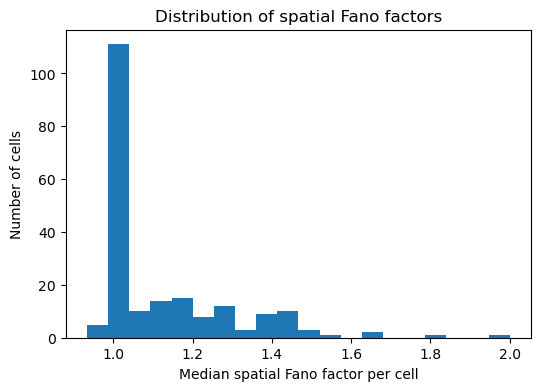

In [14]:
def compute_fano_summary_all_cells(
    spikes_by_cell, t, x, y, v,
    dt=0.1,
    n_pos_bins=150,
    min_samples_per_bin=20,
    speed_threshold=None
):
    x_edges = np.linspace(np.nanmin(x), np.nanmax(x), n_pos_bins + 1)
    y_edges = np.linspace(np.nanmin(y), np.nanmax(y), n_pos_bins + 1)

    summary = {}

    for cell_id, spike_times in spikes_by_cell.items():
        res = spatial_fano_factor_for_cell(
            spike_times=np.asarray(spike_times),
            t=t, x=x, y=y, v=v,
            dt=dt,
            x_edges=x_edges,
            y_edges=y_edges,
            min_samples_per_bin=min_samples_per_bin,
            speed_threshold=speed_threshold
        )

        valid_fano = res["fano_map"][np.isfinite(res["fano_map"])]

        summary[cell_id] = {
            "median_fano": np.nanmedian(valid_fano) if len(valid_fano) else np.nan,
            "mean_fano": np.nanmean(valid_fano) if len(valid_fano) else np.nan,
            "max_fano": np.nanmax(valid_fano) if len(valid_fano) else np.nan,
            "n_valid_bins": len(valid_fano),
            "result": res
        }

    return summary

summary = compute_fano_summary_all_cells(
    spikes_by_cell, t, x, y, v,
    dt=0.1,
    n_pos_bins=150,
    min_samples_per_bin=20,
    speed_threshold=None
)

median_fanos = np.array([summary[c]["median_fano"] for c in summary])
plt.figure(figsize=(6, 4))
plt.hist(median_fanos[np.isfinite(median_fanos)], bins=20)
plt.xlabel("Median spatial Fano factor per cell")
plt.ylabel("Number of cells")
plt.title("Distribution of spatial Fano factors")
plt.show()